# Topic classification

**Part 1 — Dataset Exploration:** Load the train split and preview its structure.

**Part 2 — BERTopic Topic Discovery:** Uses `sentence-transformers` embeddings with UMAP + HDBSCAN to discover granular topics from 10,000 train articles.

**Part 3 — Theme Classification:** Maps the 97 discovered topics to 6 editorial themes, trains a Logistic Regression classifier, and applies it to the full train split. The `id` column is preserved as the unique key throughout.

| Type | Theme |
|---|---|
| 🔴 Hard news | Politics & Conflict |
| 🔴 Hard news | Crisis, Disaster & Accidents |
| 🔴 Hard news | Crime & Law |
| 🔵 Soft news | Sports & Entertainment |
| 🔵 Soft news | Culture & Lifestyle |
| 🔵 Soft news | Science & Technology |

---
## Step 1: Install remaining dependencies

In [1]:
!pip install datasets bertopic sentence-transformers umap-learn hdbscan scikit-learn matplotlib seaborn

  Using cached datasets-4.8.4-py3-none-any.whl.metadata (19 kB)
  Using cached pyarrow-23.0.1-cp310-cp310-win_amd64.whl.metadata (3.1 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached xxhash-3.6.0-cp310-cp310-win_amd64.whl.metadata (13 kB)
  Using cached multiprocess-0.70.19-py310-none-any.whl.metadata (7.5 kB)
  Using cached aiohttp-3.13.5-cp310-cp310-win_amd64.whl.metadata (8.4 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached async_timeout-5.0.1-py3-none-any.whl.metadata (5.1 kB)
  Using cached frozenlist-1.8.0-cp310-cp310-win_amd64.whl.metadata (21 kB)
  Using cached multidict-6.7.1-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached propcache-0.4.1-cp310-cp310-win_amd64.whl.metadata (14 kB)
  Using cached yarl-1.23.0-cp310-cp310-win_amd64.whl.metadata (82 kB)
Using cached datasets-4.8.4-py3-none-any.whl (526 kB)
Using cached dill-0.4.1-py3

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from datasets import load_dataset

print("Imports successful.")

C:\Users\ASUS\anaconda3\envs\topic_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports successful.


In [3]:
# Load only the train split — this is the dataset we work with throughout
print("Loading CNN/DailyMail train split...")
ds = load_dataset("abisee/cnn_dailymail", "1.0.0")
df_train = ds["train"].to_pandas()

print(f"Train articles : {len(df_train):,}")
print(f"Columns        : {df_train.columns.tolist()}")

Loading CNN/DailyMail train split...


Train articles : 287,113
Columns        : ['article', 'highlights', 'id']


In [4]:
# Preview the first 5 rows — 'id' is the unique SHA-1 hash per article
df_train.head()

,article,highlights,id
0,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,42c027e4ff9730fbb3de84c1af0d2c506e41c3e4
1,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...,ee8871b15c50d0db17b0179a6d2beab35065f1e9
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa...",06352019a19ae31e527f37f7571c6dd7f0c5da37
3,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non...",24521a2abb2e1f5e34e6824e0f9e56904a2b0e88
4,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical...",7fe70cc8b12fab2d0a258fababf7d9c6b5e1262a


---
## BERTopic: Discovering Topics

BERTopic works in three stages:
1. **Embeddings** — `sentence-transformers` converts each article to a semantic vector
2. **Dimensionality reduction** — UMAP compresses the vectors into 5 dimensions
3. **Clustering** — HDBSCAN groups similar documents into topics

We run this on 10,000 shuffled train articles — enough to discover all major topic patterns.

In [5]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

print("BERTopic imports successful.")

BERTopic imports successful.


In [7]:
# Sample 10,000 articles from train for topic discovery
# 'id' is kept so every document stays traceable back to the original dataset
df_subset = df_train.sample(n=10000, random_state=42).reset_index(drop=True)
documents = df_subset['article'].tolist()

print(f"Documents for BERTopic: {len(documents):,}")

# Sentence-transformer embedding model — maps each article to a 384-dim semantic vector
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# UMAP — reduce from 384 to 5 dimensions before clustering
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# HDBSCAN — finds dense clusters; each cluster = one topic
hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# CountVectorizer — extracts representative keywords per topic
vectorizer_model = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)

# Build and fit BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

print("\nFitting BERTopic...")
topics, probs = topic_model.fit_transform(documents)

# Attach BERTopic results to the subset dataframe, keeping the 'id' column
df_subset['bertopic_id']   = topics
df_subset['bertopic_prob'] = probs.max(axis=1)

topic_info = topic_model.get_topic_info()
n_topics   = len(topic_info[topic_info['Topic'] != -1])
print(f"\nTopics discovered: {n_topics} (plus outlier topic -1)")
print(topic_info.head(10).to_string())

Documents for BERTopic: 10,000


Loading weights: 100%|█████████████████| 103/103 [00:00<00:00, 3926.86it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-11 16:11:00,188 - BERTopic - Embedding - Transforming documents to embeddings.



Fitting BERTopic...


Batches: 100%|███████████████████████████| 313/313 [04:36<00:00,  1.13it/s]
2026-04-11 16:15:36,882 - BERTopic - Embedding - Completed ✓
2026-04-11 16:15:36,882 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-11 16:15:50,457 - BERTopic - Dimensionality - Completed ✓
2026-04-11 16:15:50,458 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-11 16:15:52,870 - BERTopic - Cluster - Completed ✓
2026-04-11 16:15:52,882 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-11 16:16:01,948 - BERTopic - Representation - Completed ✓



Topics discovered: 86 (plus outlier topic -1)
   Topic  Count                                  Name                                                                                         Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [8]:
# Print top keywords for each discovered topic
for topic_num in sorted(topic_info['Topic'].tolist()):
    if topic_num != -1:
        words = topic_model.get_topic(topic_num)
        print(f"Topic {topic_num}: {[w for w, _ in words[:10]]}")
        print()

Topic 0: ['league', 'club', 'cup', 'season', 'england', 'team', 'game', 'players', 'manchester', 'united']

Topic 1: ['apple', 'google', 'app', 'iphone', 'users', 'facebook', 'company', 'phone', 'mobile', 'device']

Topic 2: ['obama', 'president', 'clinton', 'republican', 'house', 'republicans', 'romney', 'white house', 'campaign', 'democrats']

Topic 3: ['hospital', 'baby', 'doctors', 'heart', 'mother', 'life', 'condition', 'surgery', 'family', 'children']

Topic 4: ['fashion', 'women', 'hair', 'look', 'dress', 'model', 'like', 'style', 'new', 'make']

Topic 5: ['weight', 'food', 'diet', 'eating', 'healthy', 'meat', 'health', 'fat', 'obesity', 'eat']

Topic 6: ['sex', 'sexual', 'court', 'police', 'said', 'girl', 'told', 'year old', 'victim', 'judge']

Topic 7: ['film', 'movie', 'best', 'actor', 'comedy', 'films', 'star', 'like', 'hollywood', 'story']

Topic 8: ['court', '000', 'mr', 'money', 'jailed', 'court heard', 'police', 'prison', 'judge', 'heard']

Topic 9: ['game', 'nfl', 'nba'

These topics would then be classified into hard news or soft news.

Giving a name to each of the topics:

0. English Football Clubs & League Matches
1. Big Tech Companies & Mobile Apps
2. US Presidential & Party Politics
3. Hospitals, Childbirth & Medical Care
4. Fashion, Beauty & Personal Style
5. Diet, Weight & Healthy Eating
6. Sexual Crime & Court Cases
7. Movies & Hollywood Films
8. Court Cases, Crime & Sentencing
9. NFL & US College Sports
10. UK Politics & Government
11. Airplane Crashes & Flight Incidents
12. Olympic Games & International Sport
13. Syrian War & Middle East Conflict
14. Road Accidents & Vehicle Crashes
15. Housing Market & Real Estate
16. Music Industry & Pop Artists
17. Art, Museums & Auctions
18. Latin American Politics & Drug Trade
19. Pets, Dogs & Animal Care
20. Russia–Ukraine War & Geopolitics
21. Police Investigations & Media Scandals
22. Taxes, Welfare & Government Spending
23. Formula 1 Racing
24. Celebrity Weddings & Relationships
25. British Royal Family News
26. Missing Persons & Police Searches
27. Police Shootings & Civil Unrest Cases
28. Al-Qaeda & Terror Networks
29. Cancer, Drugs & Medical Treatments
30. War, Military & Armed Forces
31. China Politics & Government
32. Intelligence Agencies & Surveillance
33. Tennis Grand Slam Circuit
34. African Conflicts & Boko Haram
35. Ships, Piracy & Maritime Rescue
36. Sharks, Whales & Marine Life
37. Zoos & Wildlife Animals
38. North Korea Politics & Leadership
39. Space, Universe & Astronomy
40. Cars, Planes & Transport Systems
41. Mountain Climbing & Avalanche Disasters
42. Earthquakes, Volcanoes & Natural Disasters
43. Israel–Gaza Conflict
44. Boxing Matches & Championships
45. Severe Weather & Storms
46. Golf Tournaments
47. Same-Sex Marriage & Supreme Court Law
48. Online Shopping & Retail (Amazon etc.)
49. Coffee, Alcohol & Social Drinks Culture
50. Iran Nuclear Program & Sanctions
51. Ebola Outbreak & Epidemic Crisis
52. Airports, Rail & Transport Systems
53. Hospitals & Healthcare System (NHS etc.)
54. Schools, Education & Teachers
55. Murder Investigations & Homicide Cases
56. Shootings & Gun Violence Incidents
57. Evolution, Fossils & Extinction Science
58. Weather Forecasts & Temperature Reports
59. Pakistan–Afghanistan Conflict & Taliban
60. Drug Crimes & Executions
61. Women’s Tennis & Grand Slam Events
62. Flu, Viruses & Infectious Diseases
63. School Shootings (Sandy Hook etc.)
64. Nelson Mandela & African Leadership
65. Banking & Financial Sector
66. Smoking, Tobacco & Marijuana Issues
67. Travel, Resorts & Holidays
68. Fires & Firefighter Emergencies
69. Vatican, Pope & Catholic Church
70. Egypt Politics & Muslim Brotherhood
71. Local Government & Waste Management
72. Food Safety & Agriculture (GM crops etc.)
73. Oil Spills & Energy Disasters
74. NASA Missions & Space Exploration
75. French Politics & Presidency
76. India Crime & Sexual Violence Cases
77. Nuclear Power & Radiation Accidents
78. Renewable Energy & Climate Policy
79. Military Sexual Assault Cases
80. Exotic Animals & Wildlife Encounters
81. Boston Marathon Bombing
82. Dating, Relationships & Social Life
83. African Culture, Art & Entrepreneurship
84. Afghanistan War & NATO Operations
85. Airport Security & Prison Incidents

---
## Theme Classification on the Full Train Split

The BERTopic topics above are manually mapped to 6 editorial themes.
A **Logistic Regression** classifier (TF-IDF features) is trained on the labelled 10k subset,
evaluated on a held-out 20% test split, then applied to every article in the full train split.
The `id` column is the unique key linking each article to its classification throughout.

In [32]:
from collections import Counter

# =========================
# Theme Definitions
# =========================

HARD_NEWS = {
    'Politics & Conflict',
    'Crisis, Disaster & Accidents',
    'Crime & Law',
}

SOFT_NEWS = {
    'Sports & Entertainment',
    'Culture & Lifestyle',
    'Business, Science & Technology',
}

THEME_ORDER = [
    'Politics & Conflict',
    'Crisis, Disaster & Accidents',
    'Crime & Law',
    'Sports & Entertainment',
    'Culture & Lifestyle',
    'Business, Science & Technology',
]

# =========================
# Topic → Theme Mapping
# =========================

TOPIC_TO_THEME = {
    # Politics & Conflict
    2: 'Politics & Conflict',
    10: 'Politics & Conflict',
    13: 'Politics & Conflict',
    18: 'Politics & Conflict',
    20: 'Politics & Conflict',
    28: 'Politics & Conflict',
    30: 'Politics & Conflict',
    31: 'Politics & Conflict',
    32: 'Politics & Conflict',
    34: 'Politics & Conflict',
    38: 'Politics & Conflict',
    43: 'Politics & Conflict',
    47: 'Politics & Conflict',
    50: 'Politics & Conflict',
    59: 'Politics & Conflict',
    64: 'Politics & Conflict',
    70: 'Politics & Conflict',
    75: 'Politics & Conflict',
    84: 'Politics & Conflict',

    # Crisis, Disaster & Accidents
    3: 'Crisis, Disaster & Accidents',
    11: 'Crisis, Disaster & Accidents',
    14: 'Crisis, Disaster & Accidents',
    29: 'Crisis, Disaster & Accidents',
    35: 'Crisis, Disaster & Accidents',
    41: 'Crisis, Disaster & Accidents',
    42: 'Crisis, Disaster & Accidents',
    45: 'Crisis, Disaster & Accidents',
    51: 'Crisis, Disaster & Accidents',
    53: 'Crisis, Disaster & Accidents',
    58: 'Crisis, Disaster & Accidents',
    62: 'Crisis, Disaster & Accidents',
    68: 'Crisis, Disaster & Accidents',
    73: 'Crisis, Disaster & Accidents',
    77: 'Crisis, Disaster & Accidents',

    # Crime & Law
    6: 'Crime & Law',
    8: 'Crime & Law',
    21: 'Crime & Law',
    26: 'Crime & Law',
    27: 'Crime & Law',
    55: 'Crime & Law',
    56: 'Crime & Law',
    60: 'Crime & Law',
    63: 'Crime & Law',
    76: 'Crime & Law',
    79: 'Crime & Law',
    81: 'Crime & Law',
    85: 'Crime & Law',

    # Sports & Entertainment
    0: 'Sports & Entertainment',
    7: 'Sports & Entertainment',
    9: 'Sports & Entertainment',
    12: 'Sports & Entertainment',
    16: 'Sports & Entertainment',
    23: 'Sports & Entertainment',
    33: 'Sports & Entertainment',
    44: 'Sports & Entertainment',
    46: 'Sports & Entertainment',
    61: 'Sports & Entertainment',

    # Culture & Lifestyle
    4: 'Culture & Lifestyle',
    17: 'Culture & Lifestyle',
    19: 'Culture & Lifestyle',
    24: 'Culture & Lifestyle',
    25: 'Culture & Lifestyle',
    37: 'Culture & Lifestyle',
    49: 'Culture & Lifestyle',
    54: 'Culture & Lifestyle',
    67: 'Culture & Lifestyle',
    69: 'Culture & Lifestyle',
    82: 'Culture & Lifestyle',
    83: 'Culture & Lifestyle',

    # Business, Science & Technology
    1: 'Business, Science & Technology',
    15: 'Business, Science & Technology',
    22: 'Business, Science & Technology',
    36: 'Business, Science & Technology',
    39: 'Business, Science & Technology',
    40: 'Business, Science & Technology',
    48: 'Business, Science & Technology',
    52: 'Business, Science & Technology',
    57: 'Business, Science & Technology',
    65: 'Business, Science & Technology',
    71: 'Business, Science & Technology',
    74: 'Business, Science & Technology',
    78: 'Business, Science & Technology',
    80: 'Business, Science & Technology',
}


print(f"Topics mapped: {len(TOPIC_TO_THEME)}")
print(Counter(TOPIC_TO_THEME.values()))
print(f"HARD_NEWS themes: {HARD_NEWS}")
print(f"SOFT_NEWS themes: {SOFT_NEWS}")

Topics mapped: 83
Counter({'Politics & Conflict': 19, 'Crisis, Disaster & Accidents': 15, 'Business, Science & Technology': 14, 'Crime & Law': 13, 'Culture & Lifestyle': 12, 'Sports & Entertainment': 10})
HARD_NEWS themes: {'Politics & Conflict', 'Crime & Law', 'Crisis, Disaster & Accidents'}
SOFT_NEWS themes: {'Culture & Lifestyle', 'Business, Science & Technology', 'Sports & Entertainment'}


In [16]:
# Map BERTopic topic IDs to theme labels on the 10k subset
# Drop outliers (topic -1) and any IDs not in the mapping
df_subset['theme'] = df_subset['bertopic_id'].map(TOPIC_TO_THEME)
df_labelled = df_subset.dropna(subset=['theme']).copy()

print(f"Labelled training articles : {len(df_labelled):,}")
print(f"Outliers removed           : {len(df_subset) - len(df_labelled):,}")
print("\nTheme distribution in training set:")
print(df_labelled['theme'].value_counts().to_string())

Labelled training articles : 6,306
Outliers removed           : 3,694

Theme distribution in training set:
theme
Sports & Entertainment            1794
Politics & Conflict               1297
Business, Science & Technology     916
Crisis, Disaster & Accidents       900
Culture & Lifestyle                723
Crime & Law                        676


In [17]:
# ============================================================
# Train Logistic Regression classifier
# ============================================================
# TF-IDF converts article text to numeric feature vectors.
# Logistic Regression learns which word patterns predict each theme.
# We evaluate on a held-out 20% split before classifying the full dataset.

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df_labelled['article']
y = df_labelled['theme']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
        stop_words='english'
    )),
    ('lr', LogisticRegression(
        max_iter=1000,
        C=5,
        solver='lbfgs',
        multi_class='multinomial',
        random_state=42
    ))
])

print("Training classifier...")
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("\n── Classification Report (held-out 20% test set) ──")
print(classification_report(y_test, y_pred))

Training classifier...

── Classification Report (held-out 20% test set) ──
                                precision    recall  f1-score   support

Business, Science & Technology       0.86      0.86      0.86       183
                   Crime & Law       0.85      0.90      0.87       135
  Crisis, Disaster & Accidents       0.86      0.85      0.85       180
           Culture & Lifestyle       0.82      0.77      0.79       145
           Politics & Conflict       0.91      0.89      0.90       260
        Sports & Entertainment       0.94      0.96      0.95       359

                      accuracy                           0.89      1262
                     macro avg       0.87      0.87      0.87      1262
                  weighted avg       0.89      0.89      0.89      1262



In [18]:
# ============================================================
# Classify the full train split
# ============================================================
# 'id' is the primary key — it links every classified article
# back to its original entry in the CNN/DailyMail dataset.

print(f"Classifying {len(df_train):,} train articles...")

predicted_themes = clf.predict(df_train['article'])
predicted_proba  = clf.predict_proba(df_train['article'])

df_train['theme']      = predicted_themes
df_train['confidence'] = predicted_proba.max(axis=1).round(4)
df_train['news_type']  = df_train['theme'].apply(
    lambda t: 'Hard news' if t in HARD_NEWS else 'Soft news'
)

print("Done.")
print("\nTheme distribution across full train split:")
print(df_train['theme'].value_counts().to_string())

Classifying 287,113 train articles...
Done.

Theme distribution across full train split:
theme
Politics & Conflict               58768
Sports & Entertainment            58497
Crime & Law                       49649
Crisis, Disaster & Accidents      44089
Business, Science & Technology    41477
Culture & Lifestyle               34633


In [53]:
# Save — 'id' is first column so it serves as the primary key
output_cols = ['id', 'article', 'highlights', 'theme', 'news_type', 'confidence']
df_out = df_train[output_cols].copy()
df_out.to_csv('topic_classification_articles.csv', index=False, encoding='utf-8-sig')

print("Saved: topic_classification_articles.csv")
print(f"  Rows    : {len(df_out):,}")
print(f"  Columns : {df_out.columns.tolist()}")
print()

Saved: topic_classification_articles.csv
  Rows    : 287,113
  Columns : ['id', 'article', 'highlights', 'theme', 'news_type', 'confidence']



,id,article,highlights,theme,news_type,confidence
235907,4ad9665b8179a5ba2e00c8c7e0d1afeff92dbbfe,Michael Gove's advisor has slammed England's s...,Dominic Cummings has produce withering report ...,Culture & Lifestyle,Soft news,0.6024


In [58]:
df_out.sample(5)

,id,article,highlights,theme,news_type,confidence
11959,99e3c54ec9d19902a9ce2370aba86fe231bb605c,"(The Frisky) -- It didn't start out this way, ...",The iPhone is notorious for dropping calls and...,"Business, Science & Technology",Soft news,0.5212
64861,bbf5a3d8ba687a05cffbec683b93d96463c7c46c,(CNN) -- When Elizabeth Joice found out that s...,Elizabeth Joice underwent chemotherapy to beat...,"Crisis, Disaster & Accidents",Hard news,0.8059
78708,257efde1ee40726d0d3d7d6e57cd61c88399bbcf,(CNN)Let me say at the start that there is no ...,"In ""Brutally Honest"" video series, Kelly Walla...",Culture & Lifestyle,Soft news,0.4766
135394,326c5b58bb09f51897ee6681bace2d7f527cbf03,By . Ellie Zolfagharifard . PUBLISHED: . 05:05...,The blobfish was awarded the title by the Ugly...,Culture & Lifestyle,Soft news,0.5195
17086,d864849f2af19ae51ecf837533985abe3be5639c,(CNN) -- India batsman Sachin Tendulkar became...,India beat Netherlands by five wickets to book...,Sports & Entertainment,Soft news,0.9483


---
## Visualisations

In [37]:
# Shared colour palette — red tones = hard news, blue tones = soft news
THEME_COLORS = { 'Politics & Conflict' : '#922B21', 
                 'Crisis, Disaster & Accidents' : '#E74C3C', 
                 'Crime & Law' : '#F1948A', 
                 'Sports & Entertainment' : '#2E86C1', 
                 'Culture & Lifestyle' : '#85C1E9', 
                 'Business, Science & Technology' : '#1A5276',

}
TYPE_COLORS = {'Hard news': '#C0392B', 'Soft news': '#1A5276'}
hard_patch  = mpatches.Patch(color='#922B21', label='Hard news')
soft_patch  = mpatches.Patch(color='#1A5276', label='Soft news')

plt.rcParams.update({
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.dpi'       : 130,
    'font.size'        : 11,
})
print("Plot setup ready.")

Plot setup ready.


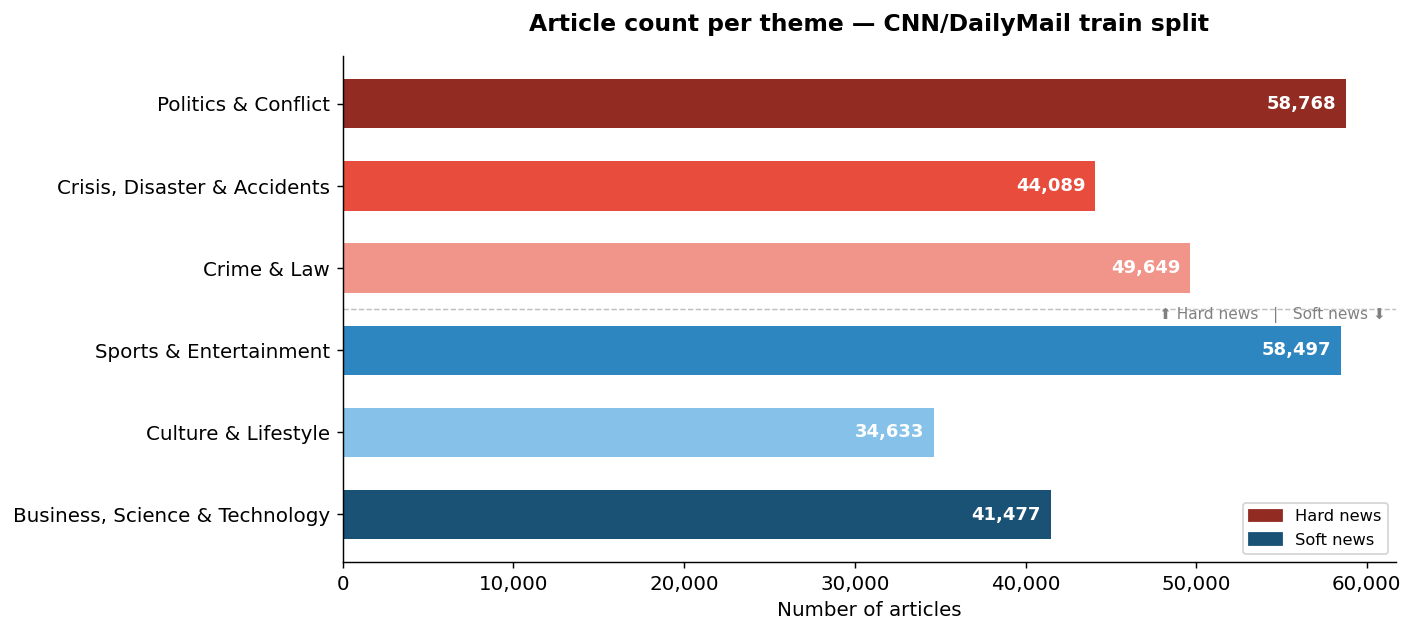

In [38]:
# Plot 1 — Article count per theme
theme_counts = df_train['theme'].value_counts().reindex(THEME_ORDER)
colors       = [THEME_COLORS[t] for t in theme_counts.index]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(theme_counts.index, theme_counts.values, color=colors, height=0.6)

for bar, val in zip(bars, theme_counts.values):
    ax.text(
        bar.get_width() - max(theme_counts.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{int(val):,}', va='center', ha='right',
        color='white', fontsize=10, fontweight='bold'
    )

ax.axhline(y=2.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.text(ax.get_xlim()[1] * 0.99, 2.62,
        '⬆ Hard news   |   Soft news ⬇', ha='right', fontsize=8.5, color='grey')
ax.set_xlabel('Number of articles')
ax.set_title('Article count per theme — CNN/DailyMail train split',
             fontsize=13, fontweight='bold', pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
ax.legend(handles=[hard_patch, soft_patch], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('plot_1_theme_counts.png', dpi=150, bbox_inches='tight')
plt.show()

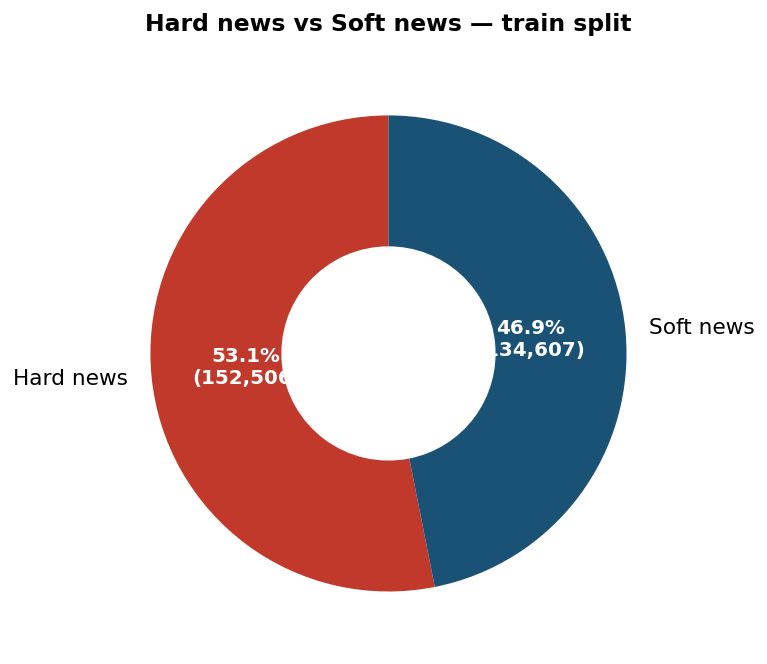

In [39]:
# Plot 2 — Hard vs Soft news split (donut chart)
type_counts = df_train['news_type'].value_counts()
total       = len(df_train)

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    type_counts.values,
    labels     = type_counts.index,
    autopct    = lambda p: f"{p:.1f}%\n({int(round(p * total / 100)):,})",
    colors     = [TYPE_COLORS[t] for t in type_counts.index],
    startangle = 90,
    wedgeprops = dict(width=0.55),
    textprops  = dict(fontsize=12),
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_color('white')
    at.set_fontweight('bold')

ax.set_title('Hard news vs Soft news — train split',
             fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('plot_2_hard_vs_soft.png', dpi=150, bbox_inches='tight')
plt.show()

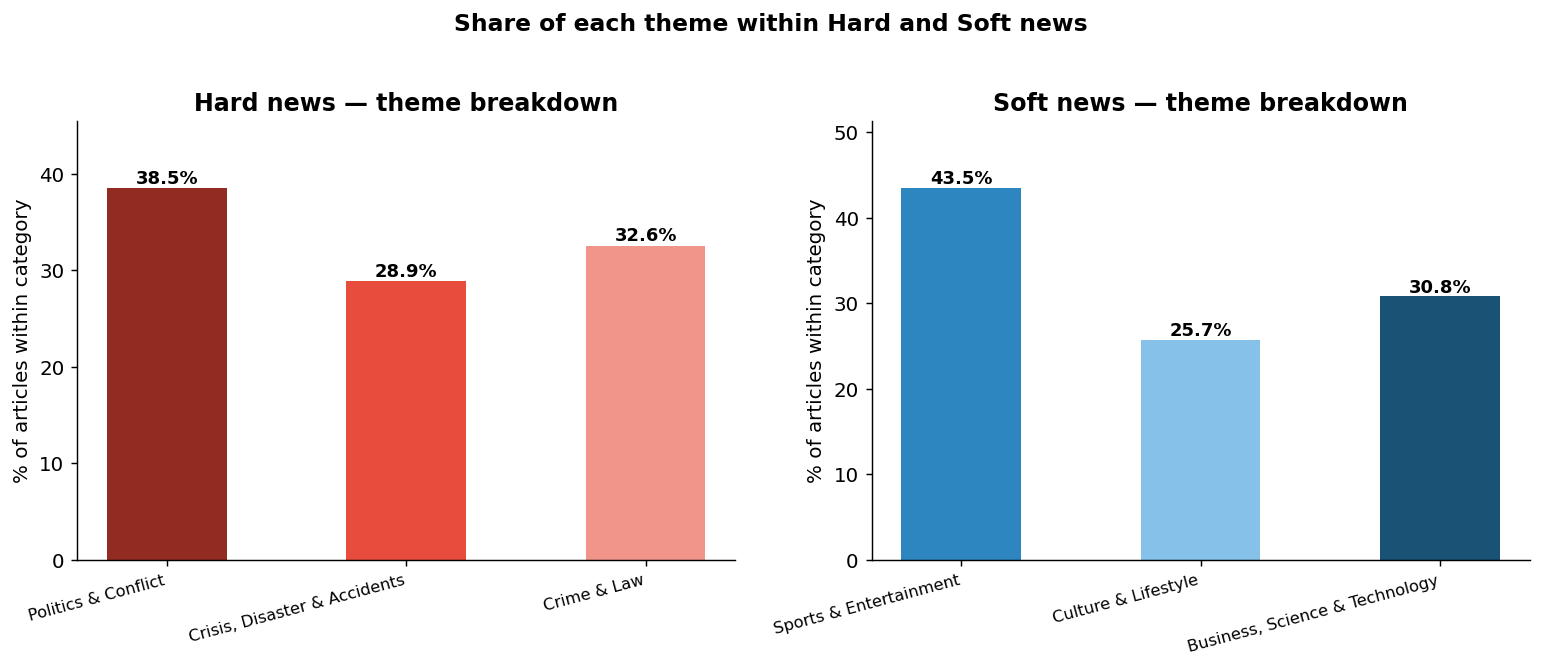

In [41]:
# Plot 3 — Theme breakdown within Hard and Soft news
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, news_type, theme_list in zip(
    axes,
    ['Hard news', 'Soft news'],
    [
        ['Politics & Conflict', 'Crisis, Disaster & Accidents', 'Crime & Law'],
        ['Sports & Entertainment', 'Culture & Lifestyle', 'Business, Science & Technology']
    ]
):
    subset = df_train[df_train['news_type'] == news_type]
    counts = subset['theme'].value_counts().reindex(theme_list)
    pcts   = counts / counts.sum() * 100
    colors = [THEME_COLORS[t] for t in pcts.index]

    bars = ax.bar(pcts.index, pcts.values, color=colors, width=0.5)
    for bar, val in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

    ax.set_ylim(0, pcts.max() * 1.18)
    ax.set_ylabel('% of articles within category')
    ax.set_title(f'{news_type} — theme breakdown', fontweight='bold')
    ax.set_xticklabels(pcts.index, rotation=15, ha='right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Share of each theme within Hard and Soft news',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_3_within_type_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3488\3480977259.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


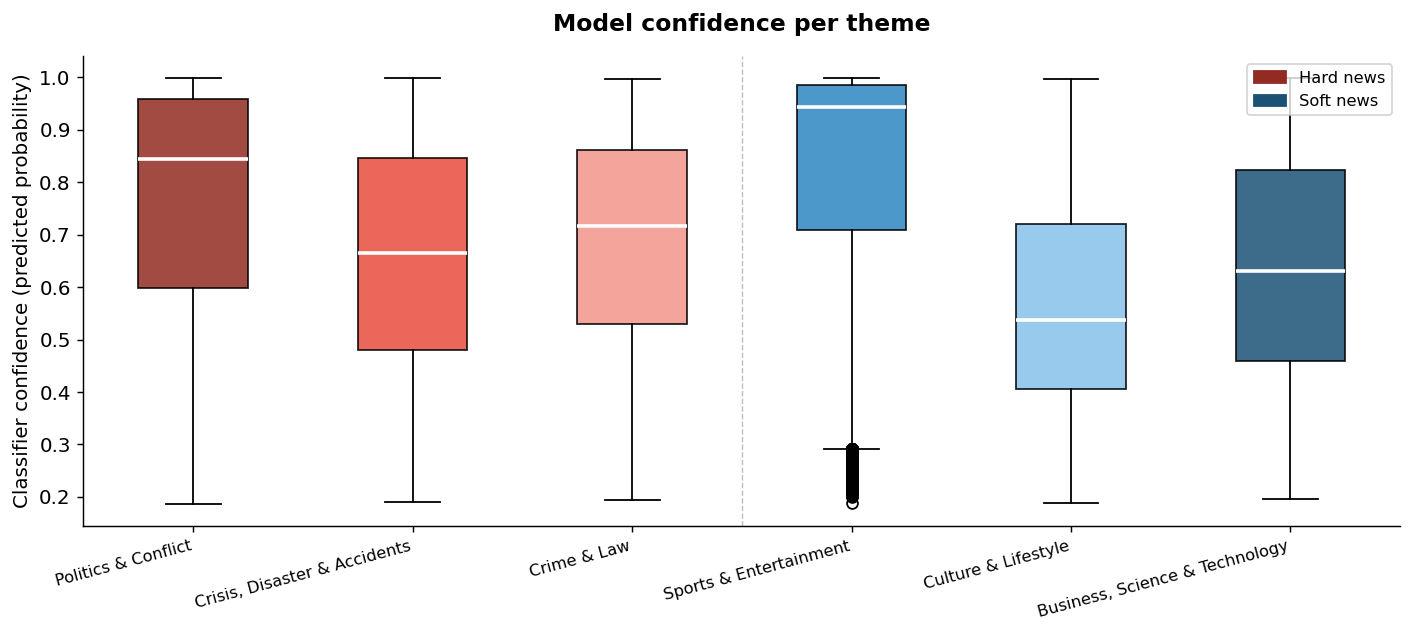

In [42]:
# Plot 4 — Classifier confidence per theme (box plot)
# Higher = model was more certain. Low-confidence themes may have
# more ambiguous articles worth inspecting.

fig, ax = plt.subplots(figsize=(11, 5))
data_by_theme = [df_train[df_train['theme'] == t]['confidence'].values for t in THEME_ORDER]

bp = ax.boxplot(
    data_by_theme,
    vert=True, patch_artist=True,
    labels=THEME_ORDER,
    medianprops=dict(color='white', linewidth=2),
)
for patch, theme in zip(bp['boxes'], THEME_ORDER):
    patch.set_facecolor(THEME_COLORS[theme])
    patch.set_alpha(0.85)

ax.set_ylabel('Classifier confidence (predicted probability)')
ax.set_title('Model confidence per theme', fontsize=13, fontweight='bold', pad=14)
ax.set_xticklabels(THEME_ORDER, rotation=15, ha='right', fontsize=9)
ax.axvline(x=3.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(handles=[hard_patch, soft_patch], loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('plot_4_confidence_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# Summary metrics table
summary = df_train.groupby('theme').agg(
    articles       = ('id',         'count'),
    unique_ids     = ('id',         'nunique'),
    pct_of_total   = ('theme',      lambda x: round(len(x) / len(df_train) * 100, 1)),
    avg_confidence = ('confidence', lambda x: round(x.mean(), 3)),
).reindex(THEME_ORDER)

summary['news_type'] = ['Hard' if t in HARD_NEWS else 'Soft' for t in summary.index]
summary = summary[['news_type', 'articles', 'unique_ids', 'pct_of_total', 'avg_confidence']]
summary.columns = ['Type', 'Articles', 'Unique IDs', '% of total', 'Avg confidence']

print('=' * 70)
print('CLASSIFICATION SUMMARY — CNN/DailyMail train split')
print('=' * 70)
print(summary.to_string())
print()
hard = (df_train['news_type'] == 'Hard news').sum()
soft = (df_train['news_type'] == 'Soft news').sum()
print(f"Total articles  : {len(df_train):,}")
print(f"Unique IDs      : {df_train['id'].nunique():,}")
print(f"Hard news       : {hard:,} ({hard/len(df_train)*100:.1f}%)")
print(f"Soft news       : {soft:,} ({soft/len(df_train)*100:.1f}%)")

CLASSIFICATION SUMMARY — CNN/DailyMail train split
                                Type  Articles  Unique IDs  % of total  Avg confidence
theme                                                                                 
Politics & Conflict             Hard     58768       58768        20.5           0.769
Crisis, Disaster & Accidents    Hard     44089       44089        15.4           0.658
Crime & Law                     Hard     49649       49649        17.3           0.689
Sports & Entertainment          Soft     58497       58497        20.4           0.826
Culture & Lifestyle             Soft     34633       34633        12.1           0.568
Business, Science & Technology  Soft     41477       41477        14.4           0.638

Total articles  : 287,113
Unique IDs      : 287,113
Hard news       : 152,506 (53.1%)
Soft news       : 134,607 (46.9%)
